<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D0%B0_%D0%B0%D0%B2%D1%82%D0%BE%D0%BA%D0%BE%D0%B4%D0%B8%D1%80%D0%BE%D0%B2%D1%89%D0%B8%D0%BA%D0%B0_(Autoencoder)_%7C_%D0%94%D0%97_Ultra_Pro_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задание
**Создайте автокодировщик, который будет восстанавливать изображения из базы Mnist, в случайных местах которых будут находиться чёрные квадраты размером 8x8.**

Для этого:
1. Подготовьте базу данных изображений Mnist.
2. Добавьте на изображения случайные чёрные квадраты размера 8x8 пикселей.
3. Создайте и обучите автокодировщик восстанавливать оригинальные изображения.
4. Добейтесь того, чтобы средняя квадратичная ошибка (MSE) на тестовой выборке была меньше 0,0070."

## Импорт библиотек

In [1]:
# Отображение
import matplotlib.pyplot as plt

# Для работы с тензорами
import numpy as np

# Класс создания модели
from tensorflow.keras.models import Model

# Для загрузки данных
from tensorflow.keras.datasets import mnist

# Необходимые слои
from tensorflow.keras.layers import Input, Conv2DTranspose, MaxPooling2D, Conv2D, BatchNormalization

# Оптимизатор
from tensorflow.keras.optimizers import Adam

## Данные

In [2]:
# Загрузка данных
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Нормировка данных
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

In [4]:
# Изменение формы под удобную для Keras
X_train = X_train.reshape((-1, 28, 28, 1))
X_test = X_test.reshape((-1, 28, 28, 1))

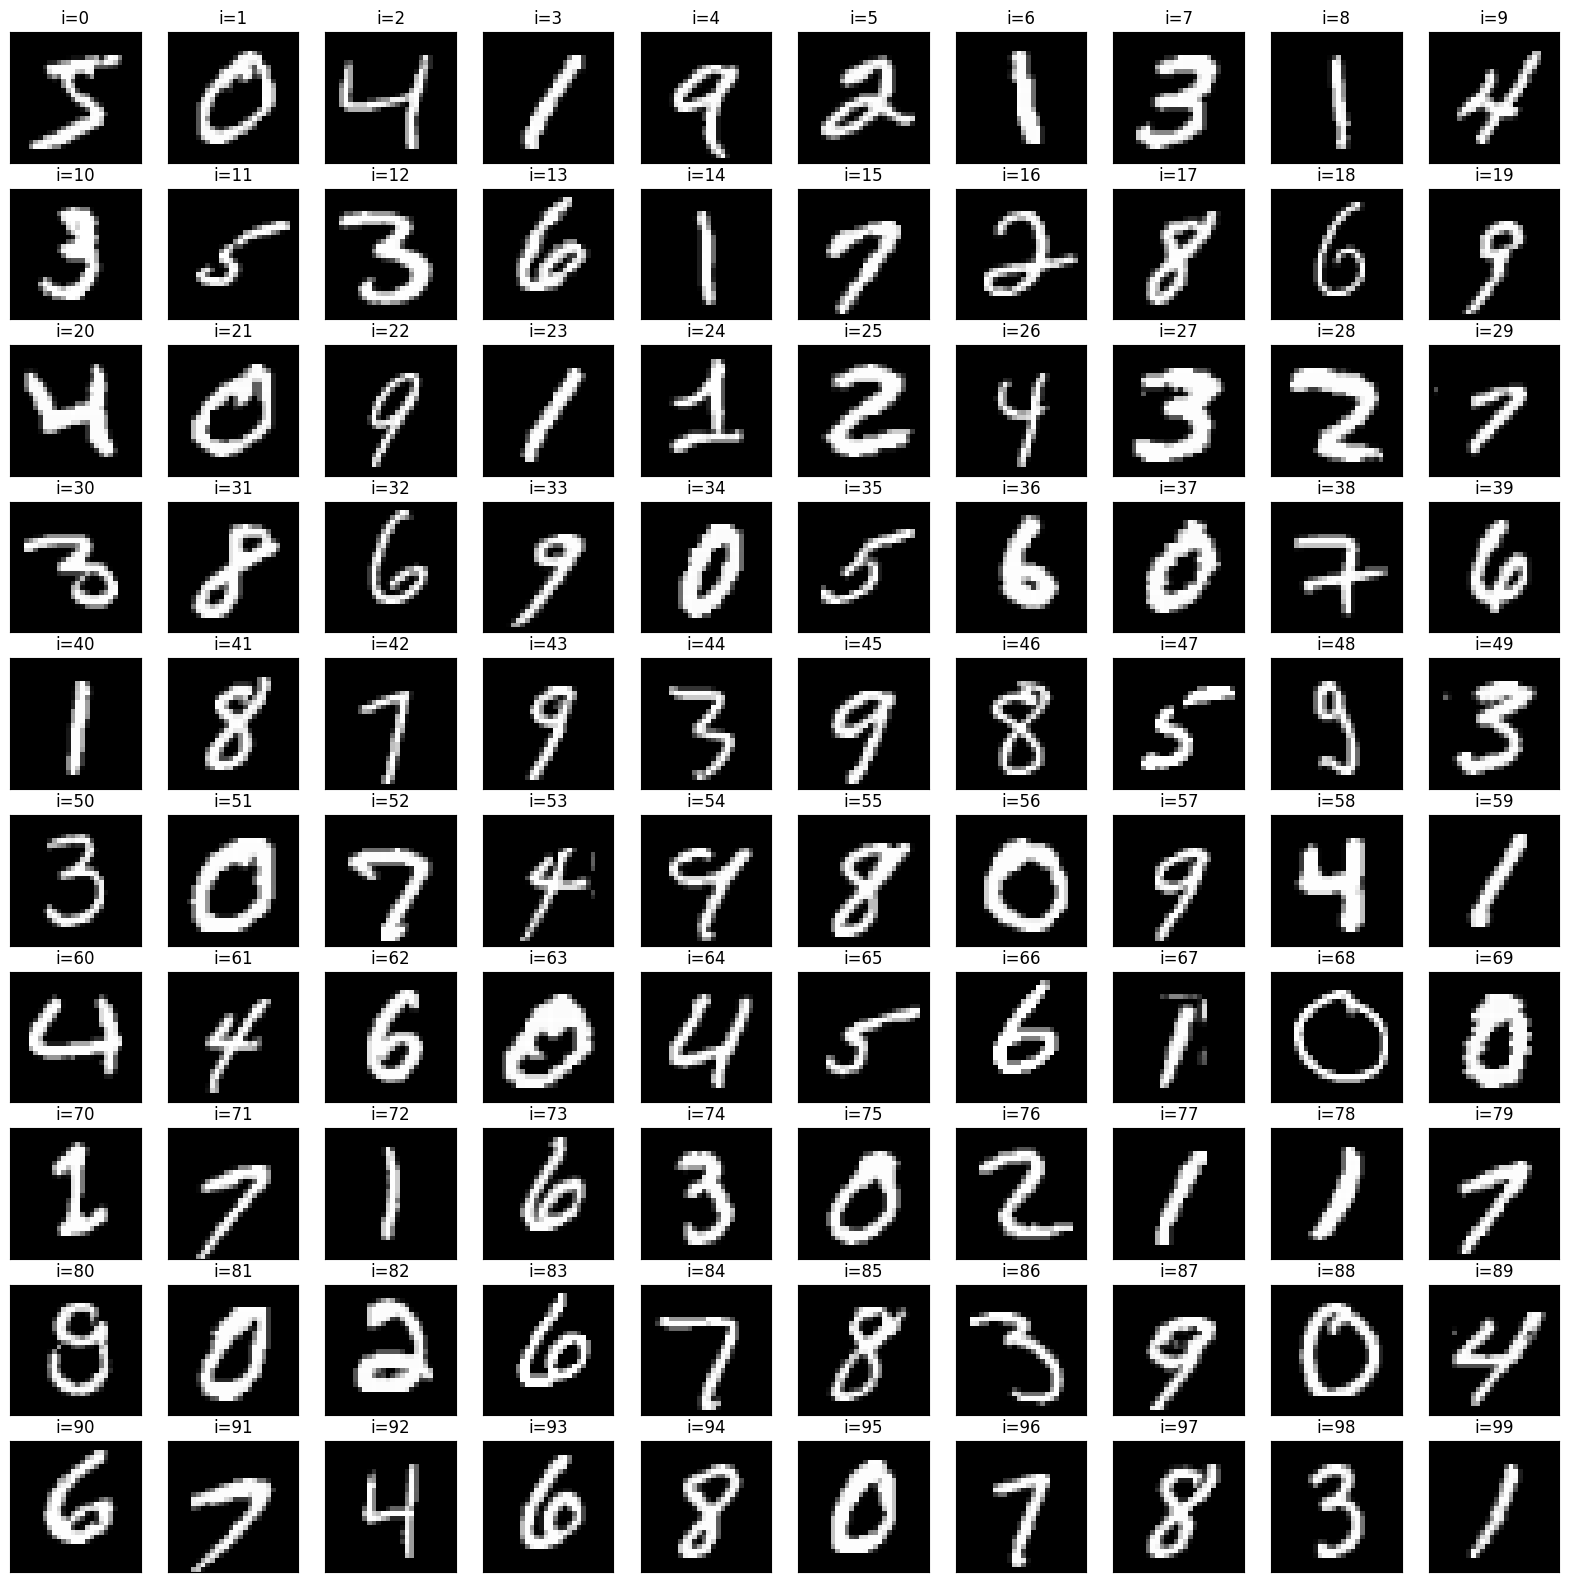

In [5]:
# Ваше решение
# и вывод части (100) картинок из тренировочного набора
plt.figure(figsize=(20, 20))
for i in range(0, 100):
    ax = plt.subplot(10, 10, i+1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.title(f'i={i}')
plt.show()

In [6]:
#функция добавления квадратов
def add_black_square_to_images(x_train):
    rng = np.random.default_rng()
    for i in range(x_train.shape[0]):
        square_size = 8
        max_corner_y = x_train.shape[1]-square_size
        max_corner_x = x_train.shape[2]-square_size
        res = rng.integers(min(max_corner_y, max_corner_x), size=2)
        corner_y = res[0]
        corner_x = res[1]
        for row in range(corner_y, corner_y+square_size):
            for col in range(corner_x, corner_x+square_size):
                x_train[i][row][col][0] = 0.0

(60000, 28, 28, 1)


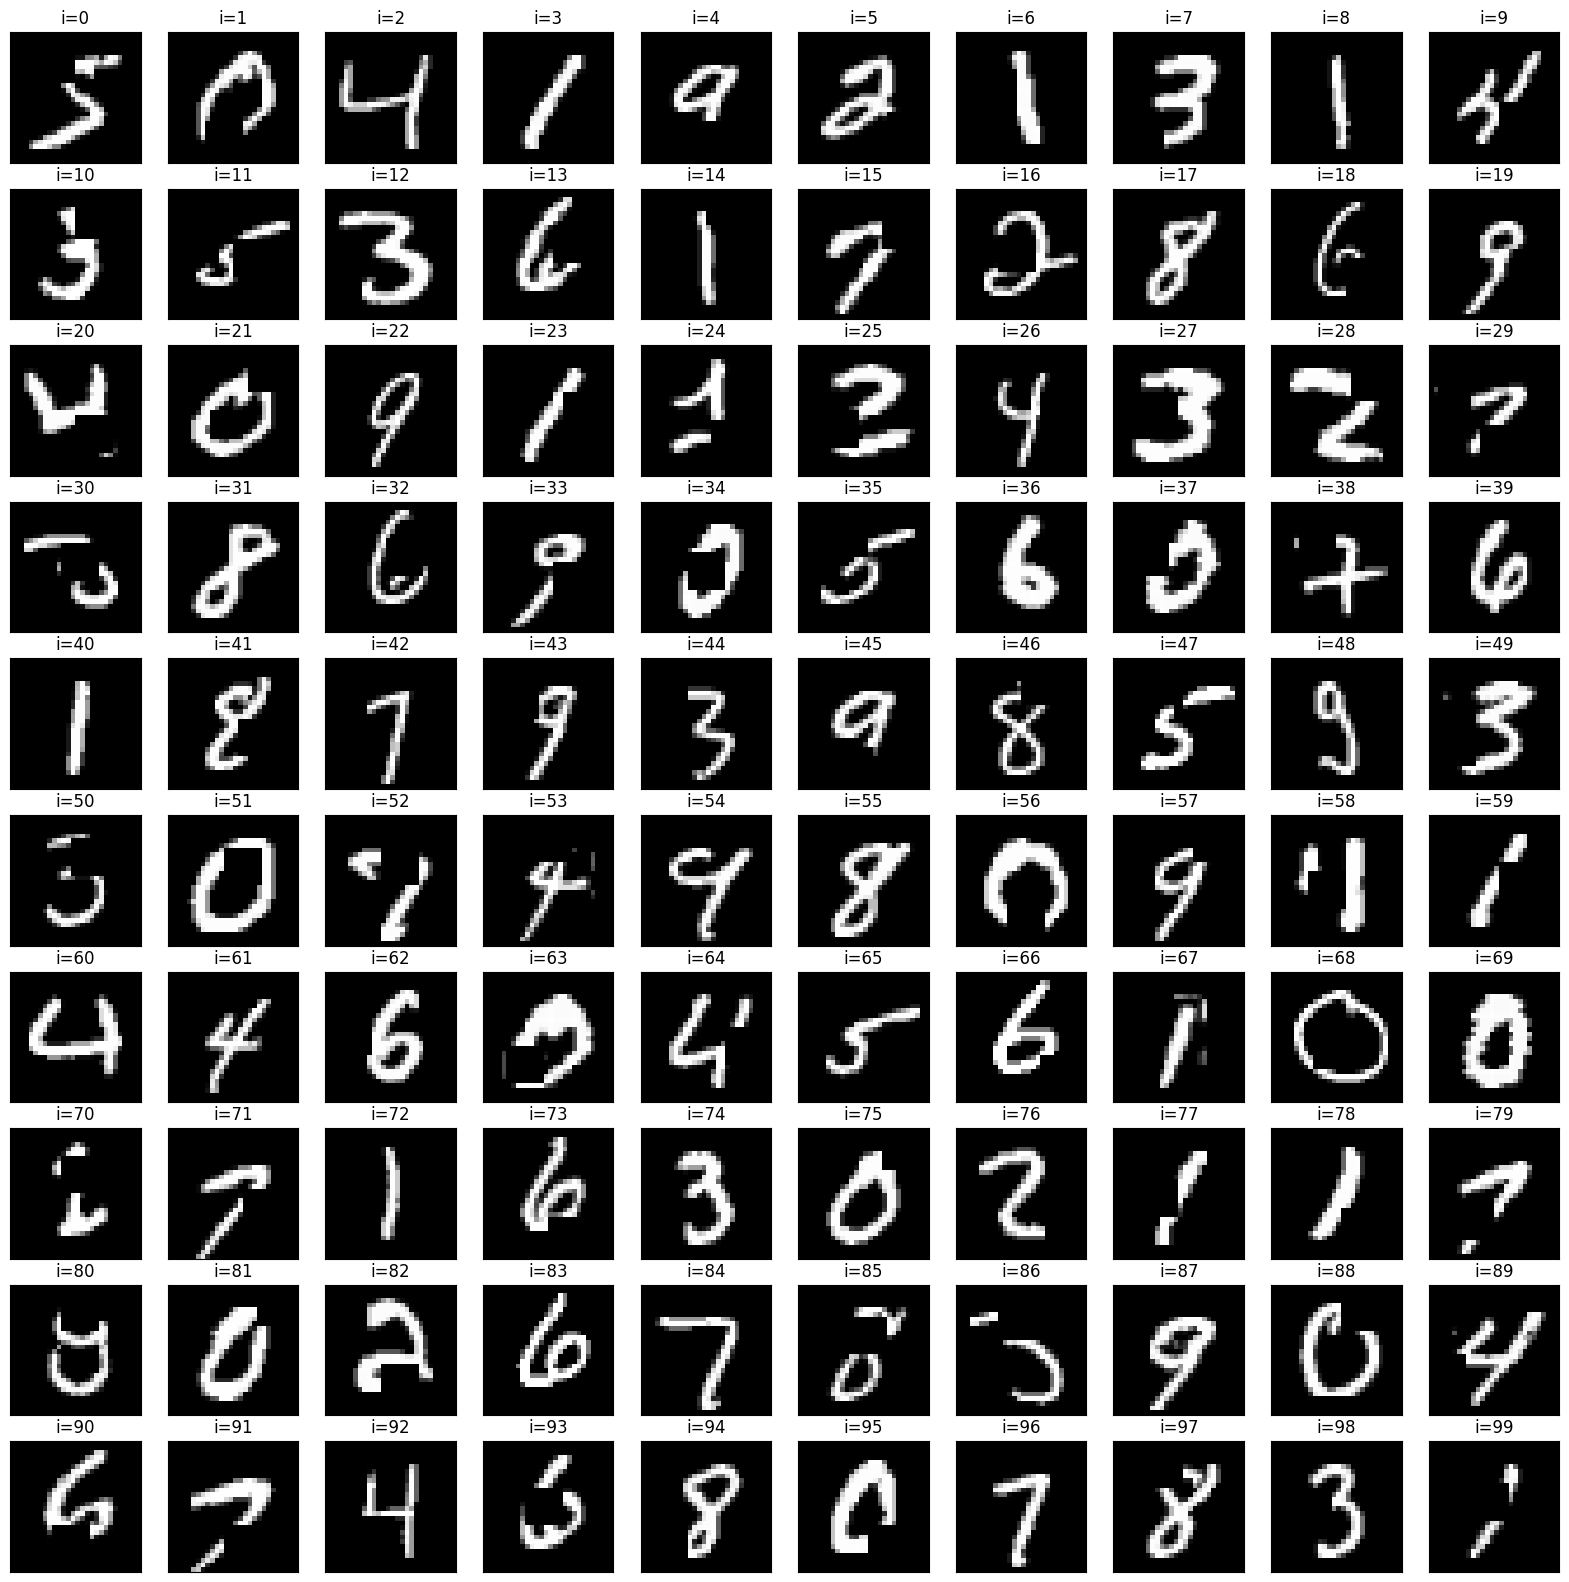

In [7]:
#подготовка изображений с квадратами
X_train_noise = np.array([])
#копируем тренировочный набор
X_train_noise = np.copy(X_train)
#и накладывем квадраты
add_black_square_to_images(X_train_noise)
print(X_train_noise.shape)
# и вывод части (100) картинок из набора c квадратами
plt.figure(figsize=(20, 20))
for i in range(0, 100):
    ax = plt.subplot(10, 10, i+1)
    plt.imshow(X_train_noise[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.title(f'i={i}')
plt.show()

In [8]:
# Функция сборки сверточного автокодировщика
def create_base_ae(in_shape):
    # Энкодер, вход нейросети
    img_input = Input(in_shape)

    # Энкодер, первый блок
    # 1.1. Двумерная свертка
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(img_input)
    # 1.2. Нормализация
    x = BatchNormalization()(x)
    # 1.3. Двумерная свертка
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    # 1.4. Нормализация
    x = BatchNormalization()(x)
    # 1.5. Снижение размерности и обобщение данных
    x = MaxPooling2D()(x)

    # Энкодер, второй блок
    # 2.1. Двумерная свертка
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    # 2.2. Нормализация
    x = BatchNormalization()(x)
    # 2.3. Двумерная свертка
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    # 2.4. Нормализация
    x = BatchNormalization()(x)


    # На выходе кодировщика и на входе декодировщика z - вектор латентного пространства
    # 2.5. Снижение размерности и обобщение данных
    z = MaxPooling2D()(x)


    # Декодер, первый блок
    # 1.1. Транспонированная свертка - повышение размерности данных
    x = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', activation='relu')(z)
    # 1.2. Нормализация
    x = BatchNormalization()(x)
    # 1.3. Двумерная свертка
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    # 1.4. Нормализация
    x = BatchNormalization()(x)
    # 1.5. Двумерная свертка
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    # 1.6. Нормализация
    x = BatchNormalization()(x)

    # Декодер, второй блок
    # 2.1. Транспонированная свертка - повышение размерности данных
    x = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same', activation='relu')(x)
    # 2.2. Нормализация
    x = BatchNormalization()(x) # слой нормализации данных
    # 2.3. Двумерная свертка
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    # 2.4. Нормализация
    x = BatchNormalization()(x) # слой нормализации данных
    # 2.5. Двумерная свертка
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    # 2.6. Нормализация
    x = BatchNormalization()(x)

    # Декодер, финальный слой двумерной свертки, выдающий итоговое изображение
    outputs = Conv2D(in_shape[-1], (3, 3), activation='sigmoid', padding='same')(x)

    # Сборка модели, на входе оригинальное изображение, на выходе - сжатое-восстановленное
    model = Model(inputs=img_input, outputs=outputs)

    # Компиляция сети, назначение оптимизатора Adam + среднеквадратическая ошибка
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse')

    # Возврат готовой модели
    return model

In [28]:
# Функция последовательного вывода нескольких изображений для сравнения
def plot_images(x_data, data_noise, pred, n=10):

    plt.figure(figsize=(20, 7))                     # Размер полотна

    for i in range(1, n + 1):                              # Повтор n раз:
        index = np.random.randint(0, pred.shape[0]) # Выбор случайного индекса

        # Показ картинки с индексом index из набора x_data
        ax = plt.subplot(3, n, i)               # Картинка располагается в верхнем ряду
        plt.imshow(x_data[index].squeeze(), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Показ картинки с индексом index из набора зашумленных
        ax = plt.subplot(3, n, i+n)               # Картинка располагается в среднем ряду
        plt.imshow(data_noise[index].squeeze(), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Показ картинки с тем же индексом из предсказания автокодировщика
        ax = plt.subplot(3, n, i + n + n)           # Картинка располагается в нижнем ряду
        plt.imshow(pred[index].squeeze(), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

In [10]:
# Сборка автокодировщика для формы картинок датасета
ae_mnist = create_base_ae(X_train.shape[1:])

In [11]:
# Сводка архитектуры автокодировщика
ae_mnist.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        16,448 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         8,224 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │         9,24

 Total params: 184,225 (719.63 KB)

 Trainable params: 183,265 (715.88 KB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
def model_check(model):
  # Входная форма
  input_shape = model.input.shape[1:]

  # Выходная форма
  output_shape = model.output.shape[1:]

  # Сравнение
  assert input_shape == output_shape, f'Вход и выход не совпадают по форме, input: {input_shape}, output'

In [13]:
model_check(ae_mnist)

In [31]:
# Обучение модели автокодировщика, на входе и выходе одни и те же данные
history = ae_mnist.fit(X_train_noise, X_train,
                       epochs=50,
                       batch_size=256,
                       validation_split = 0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 0.0117 - val_loss: 0.0120
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.0062 - val_loss: 0.0077
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.0055 - val_loss: 0.0060
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 0.0052 - val_loss: 0.0058
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.0050 - val_loss: 0.0053
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.0048 - val_loss: 0.0050
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0047 - val_loss: 0.0050
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.0046 - val_loss: 0.0048
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.0045 - val_loss: 0.0049
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.0044 - val_loss: 0.0052
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.0043 - val_loss: 0.0050
Epoch 12/50
188/188 ━━━━━━━━━━━━━━

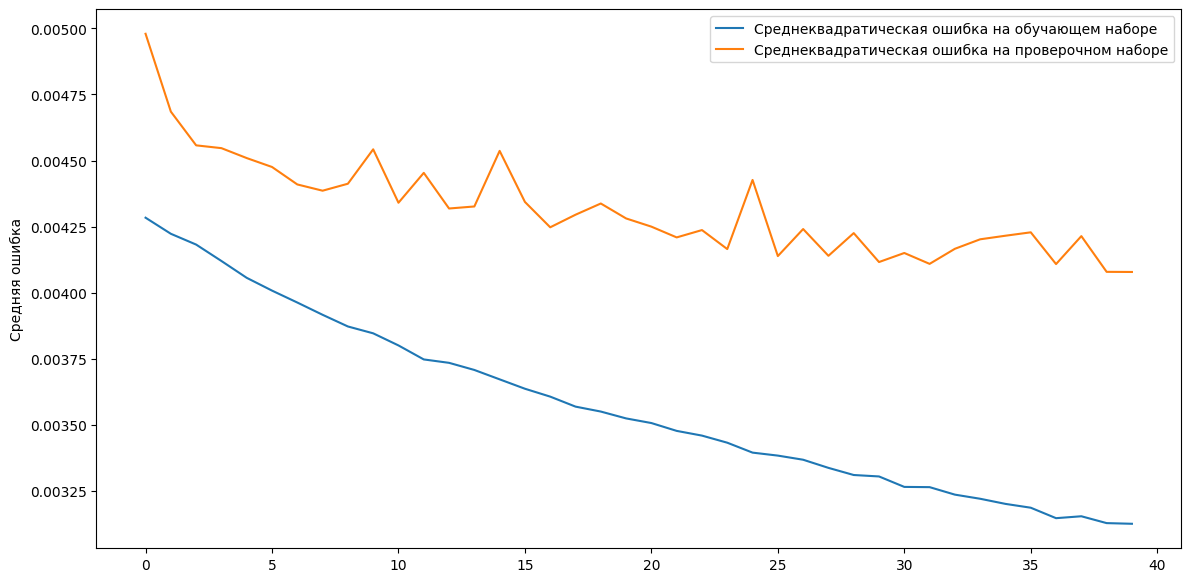

In [32]:
# Вывод графиков процесса обучения
plt.figure(figsize=(14,7))
plt.plot(history.history['loss'][10:],
         label='Среднеквадратическая ошибка на обучающем наборе')
plt.plot(history.history['val_loss'][10:],
         label='Среднеквадратическая ошибка на проверочном наборе')
plt.ylabel('Средняя ошибка')
plt.legend()
plt.show()

In [33]:
# Получение предсказания автокодировщика на наборе с квадратами
X_pred_train_noise = ae_mnist.predict(X_train_noise)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


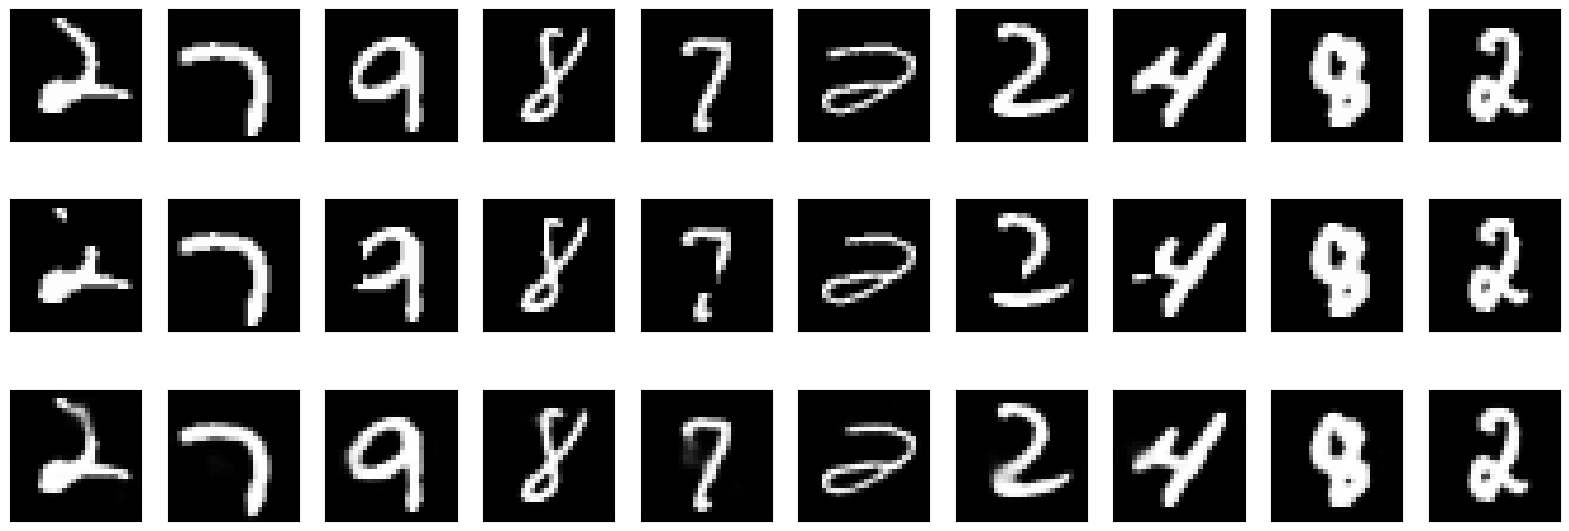

In [34]:
# Сравнение исходных и восстановленных картинок
plot_images(X_train, X_train_noise, X_pred_train_noise)